# Final evaluation for all models

This notebook covers evaluation of all ten models trained across the three approaches, all scored on the **official IPN Hand test split** with the shared `src/evaluation/metrics.py` module, so every number below is directly comparable.

| Approach | Models | Notebook |
|---|---|---|
| Landmark statistics (aggregated) | KNN, SVM linear, SVM RBF, Random Forest | `04_classical_models.ipynb` |
| Landmark sequences (RNN) | LSTM, GRU, BiGRU, BiLSTM | `05_lstm_models.ipynb` |
| Raw video clips (pixels) | 3D CNN from scratch, R(2+1)D-18 pretrained | `06_3dcnn_models.ipynb` |

Contents:
1. Load all saved results
2. Joint results table
3. Overall metric comparison
4. Accuracy vs speed trade-off
5. Per-class comparison
6. Confusion matrices
7. Conclusions

## 1. Load all saved results

Every notebook saves its final test-set metrics as JSON in `results/`, so nothing is retrained here.

In [3]:
import sys
sys.path.insert(0, '..')

import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "../results"
FIG_DIR = "../results/figures/comparison"
os.makedirs(FIG_DIR, exist_ok=True)

# (json file, display name, approach)
MODEL_FILES = [
    ("KNN_results.json",           "KNN",            "Landmark stats"),
    ("SVM_linear_results.json",    "SVM linear",     "Landmark stats"),
    ("SVM_rbf_results.json",       "SVM RBF",        "Landmark stats"),
    ("RandomForest_results.json",  "Random Forest",  "Landmark stats"),
    ("LSTM_results.json",          "LSTM",           "Landmark seq"),
    ("GRU_results.json",           "GRU",            "Landmark seq"),
    ("BiGRU_results.json",         "BiGRU",          "Landmark seq"),
    ("BiLSTM_results.json",          "BiLSTM",         "Landmark seq"),
    ("3dcnn_scratch_results.json", "3D CNN scratch", "Video pixels"),
    ("r2plus1d_results.json",      "R(2+1)D-18",     "Video pixels"),
]

results = {}
for filename, display_name, approach in MODEL_FILES:
    with open(os.path.join(RESULTS_DIR, filename)) as f:
        data = json.load(f)
    data['display_name'] = display_name
    data['approach'] = approach
    results[display_name] = data

print(f"Loaded {len(results)} model results")

Loaded 10 model results


## 2. Joint results table

Inference time is per single gesture on CPU. The classical models store it as
`inference_mean_ms`, the deep models as `inference_ms`; parameter counts do not apply to
KNN/SVM/Random Forest.

In [4]:
rows = []
for name, r in results.items():
    inference_ms = r.get('inference_mean_ms', r.get('inference_ms'))
    rows.append({
        'Model': name,
        'Approach': r['approach'],
        'Accuracy': r['accuracy'],
        'F1 (weighted)': r['f1_weighted'],
        'F1 (macro)': r['f1_macro'],
        'Inference (ms)': inference_ms,
        'Parameters': r.get('parameters'),
        'Train time (s)': r.get('train_time_s'),
    })

comparison_df = pd.DataFrame(rows).sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)
comparison_df.to_csv(os.path.join(RESULTS_DIR, "final_comparison.csv"), index=False)

comparison_df.style.format({
    'Accuracy': '{:.4f}', 'F1 (weighted)': '{:.4f}', 'F1 (macro)': '{:.4f}',
    'Inference (ms)': '{:.2f}', 'Parameters': '{:,.0f}', 'Train time (s)': '{:.1f}',
}, na_rep='-').background_gradient(subset=['Accuracy', 'F1 (weighted)', 'F1 (macro)'], cmap='Blues')

,Model,Approach,Accuracy,F1 (weighted),F1 (macro),Inference (ms),Parameters,Train time (s)
0,R(2+1)D-18,Video pixels,0.9083,0.9090,0.8699,132.03,"31,306,794",-
1,BiLSTM,Landmark seq,0.8774,0.8761,0.8372,1.86,"674,701",-
2,BiGRU,Landmark seq,0.8656,0.8645,0.8094,4.55,"510,349",874.3
3,SVM RBF,Landmark stats,0.8474,0.8478,0.7723,1.25,-,3.6
4,SVM linear,Landmark stats,0.8447,0.8452,0.7623,0.86,-,2.6
5,GRU,Landmark seq,0.8483,0.8444,0.7718,3.44,"206,477",515.9
6,LSTM,Landmark seq,0.8320,0.8225,0.7478,1.23,"272,269",1042.8
7,Random Forest,Landmark stats,0.8029,0.7999,0.7075,16.23,-,8.3
8,KNN,Landmark stats,0.6866,0.6743,0.5841,5.11,-,0.0
9,3D CNN scratch,Video pixels,0.5277,0.4638,0.5173,9.80,"1,199,821",-


**Reading the table**

R(2+1)D-18 now leads outright at 0.909 weighted F1 - about 3 points clear of the next tier, BiLSTM (0.876) and BiGRU (0.864), which remain close to each other. Below them, a dense middle band — SVM RBF, GRU, SVM linear, LSTM — they all land between 0.822 and 0.848.

The two clear outliers are at the bottom: KNN (0.674) and the from-scratch 3D CNN (0.464). They fail for opposite reasons - KNN because a distance metric over aggregated statistics discards temporal structure, and the 3D CNN because ~3,100 clips are not enough to learn useful spatiotemporal filters from raw pixels.

Macro F1 separates the models more sharply than accuracy does, because it weights the eleven rare classes equally with the two dominant `Point` classes. On that metric the ranking is the same, but the spread widens further: R(2+1)D-18 (0.870) pulls ahead of BiLSTM (0.837) by more than it does on weighted F1, and both stay well clear of the classical models (0.584-0.772).

## 3. Overall metric comparison

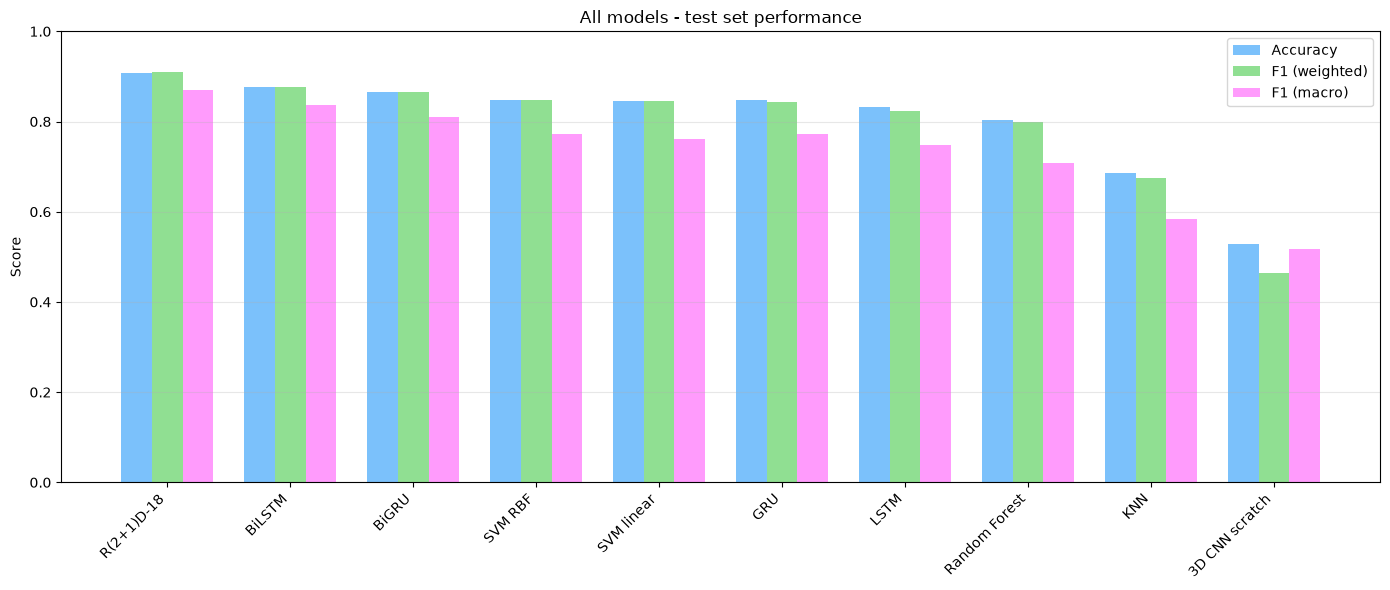

In [5]:
plot_df = comparison_df.copy()
x = np.arange(len(plot_df))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, plot_df['Accuracy'], width, label='Accuracy', color="#7BC1FB")
ax.bar(x, plot_df['F1 (weighted)'], width, label='F1 (weighted)', color="#90DF92")
ax.bar(x + width, plot_df['F1 (macro)'], width, label='F1 (macro)', color="#FF9BFC")

ax.set_ylabel('Score')
ax.set_title('All models - test set performance')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Model'], rotation=45, ha='right')
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "all_models_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()

The three metrics order the models identically.The macro F1 bar is consistently the shortest - every model finds the rare classes harder than the frequent ones, but the size of that drop is itself informative: it is small for the deep sequence models (BiLSTM 0.876 to 0.837) and large for the classical ones (KNN 0.674 to 0.584, Random Forest 0.800 to 0.707), meaning the classical models lean much more heavily on the two dominant `Point` classes for their score.

## 4. Accuracy vs speed trade-off

For a real-time demo the model has to keep up with a 30 fps webcam, i.e. one frame every 33 ms. Note the log scale on the x-axis - inference times span three orders of magnitude.

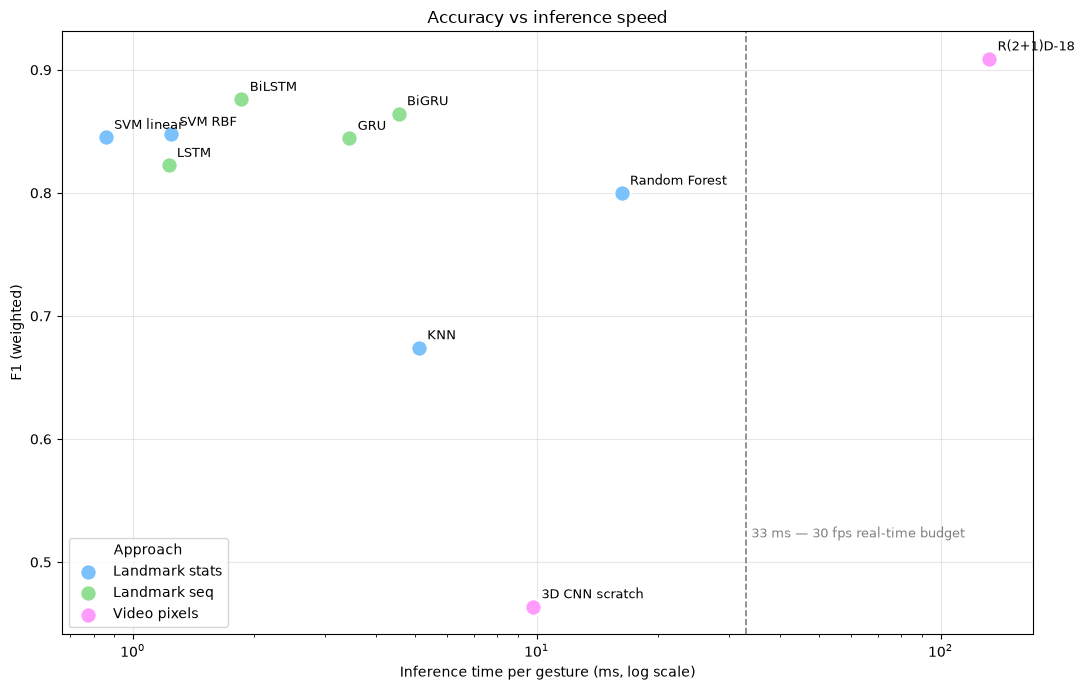

In [6]:
fig, ax = plt.subplots(figsize=(11, 7))

approach_colors = {
    'Landmark stats': "#7BC1FB",
    'Landmark seq': "#90DF92",
    'Video pixels': "#FF9BFC",
}

for approach, color in approach_colors.items():
    subset = comparison_df[comparison_df['Approach'] == approach]
    ax.scatter(subset['Inference (ms)'], subset['F1 (weighted)'],
               s=140, color=color, edgecolor='white', linewidth=1.5,
               label=approach, zorder=3)

for _, row in comparison_df.iterrows():
    ax.annotate(row['Model'],
                xy=(row['Inference (ms)'], row['F1 (weighted)']),
                xytext=(6, 6), textcoords='offset points', fontsize=9)

ax.axvline(33, color='gray', linestyle='--', linewidth=1.2)
ax.text(34, 0.52, '33 ms — 30 fps real-time budget', fontsize=9, color='gray')

ax.set_xscale('log')
ax.set_xlabel('Inference time per gesture (ms, log scale)')
ax.set_ylabel('F1 (weighted)')
ax.set_title('Accuracy vs inference speed')
ax.legend(title='Approach')
ax.grid(alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "accuracy_vs_speed.png"), dpi=150, bbox_inches='tight')
plt.show()

Everything except R(2+1)D-18 stands left of the 33 ms line, so speed is not the deciding factor among the landmark-based models - all of them run 7x to 38x faster than real-time.

R(2+1)D-18 is the exception at 132 ms per clip, roughly 4x over the real-time budget on CPU (it was also the only model that needed a GPU to train, on Colab). This time it buys a real accuracy gain, not just a marginal one: 0.909 weighted F1 against BiLSTM's 0.876, a 3.3-point gap that also holds on macro F1 (0.870 vs 0.837) - at 31.3M parameters against BiLSTM's 675k, 46x the model, and roughly 70x the latency.

BiLSTM remains the practical choice for real-time or CPU-only deployment: it gives up those 3 points for two orders of magnitude in speed (1.86 ms) and does not need the pixel pipeline at all. Whether that trade is worth it depends on the application - it is not a free lunch either way. Among the classical models, SVM linear is the standout - 0.845 weighted F1 at 0.86 ms, the fastest model in the whole comparison.

One thing about these numbers: the landmark-based timings measure classification only, and exclude the MediaPipe extraction step that has to run first on every frame. The pixel models need no such preprocessing, so their end-to-end disadvantage is smaller than the plot suggests.

## 5. Per-class comparison

Per-class F1 is available for the models that stored it (the classical models directly, the RNN models inside their saved classification report). BiLSTM, 3D CNN and R(2+1)D-18 saved only summary metrics, so they are discussed from their own notebooks rather than shown here.

In [7]:
from src.evaluation.metrics import CLASS_NAMES

# Get per-class F1 from either the stored dict or the classification report text
def parse_per_class_f1(result):
    
    if 'per_class_f1' in result:
        return result['per_class_f1']
    if 'report' in result:
        per_class = {}
        for line in result['report'].split('\n'):
            for class_name in CLASS_NAMES:
                if line.strip().startswith(class_name):
                    per_class[class_name] = float(line.split()[-2])
        return per_class
    return None

per_class_data = {}
for name, r in results.items():
    parsed = parse_per_class_f1(r)
    if parsed and len(parsed) == len(CLASS_NAMES):
        per_class_data[name] = parsed

per_class_df = pd.DataFrame(per_class_data).reindex(CLASS_NAMES)
print("Models with per-class data:", list(per_class_df.columns))

per_class_df.style.format('{:.2f}').background_gradient(cmap='RdYlGn', vmin=0, vmax=1, axis=None)

Models with per-class data: ['KNN', 'SVM linear', 'SVM RBF', 'Random Forest', 'LSTM', 'GRU', 'BiGRU']


,KNN,SVM linear,SVM RBF,Random Forest,LSTM,GRU,BiGRU
Point-1f,0.80,0.98,0.96,0.94,0.94,0.96,0.96
Point-2f,0.84,0.97,0.97,0.95,0.94,0.96,0.94
Click-1f,0.29,0.49,0.48,0.42,0.59,0.39,0.69
Click-2f,0.26,0.55,0.56,0.41,0.43,0.50,0.59
Throw-up,0.48,0.82,0.84,0.79,0.84,0.76,0.80
Throw-down,0.82,0.93,0.94,0.91,0.93,0.86,0.90
Throw-left,0.89,0.96,0.96,0.95,0.99,1.00,0.99
Throw-right,0.81,0.83,0.88,0.87,0.90,0.82,0.84
Open-twice,0.65,0.84,0.87,0.81,0.81,0.81,0.84
DblClick-1f,0.40,0.55,0.57,0.43,0.09,0.64,0.69


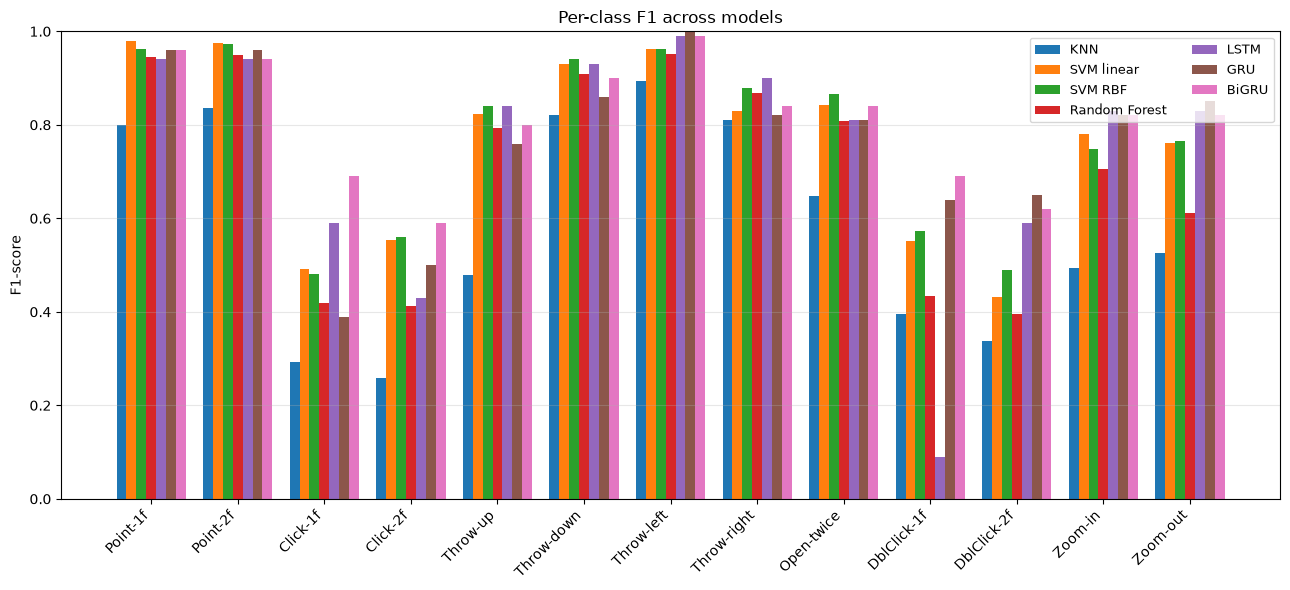

In [8]:
fig, ax = plt.subplots(figsize=(13, 6))

n_models = len(per_class_df.columns)
x = np.arange(len(CLASS_NAMES))
width = 0.8 / n_models

for i, model in enumerate(per_class_df.columns):
    offset = (i - (n_models - 1) / 2) * width
    ax.bar(x + offset, per_class_df[model], width, label=model)

ax.set_ylabel('F1-score')
ax.set_title('Per-class F1 across models')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_ylim(0, 1.0)
ax.legend(ncol=2, fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "per_class_f1_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()


**The same four classes are hardest for every model.** `Click-1f`, `Click-2f`, `DblClick-1f` and `DblClick-2f` are the lowest-scoring classes for every single model in the table - 0.26-0.40 for KNN, 0.40-0.43 for Random Forest, 0.43-0.57 for the SVMs, 0.59-0.69 for BiGRU, and 0.63-0.74 for BiLSTM (from its own notebook). No other class family behaves this way: excluding KNN, the two `Point` classes score 0.94-0.98 everywhere and the `Throw` family 0.76-1.00.

The fact that this pattern survives four fundamentally different algorithms says it is a property of the **task**, not of any of the models. These four gestures share a hand shape and a motion, so they differ only in how many fingers are extended and how many times the motion repeats. Counting repetitions is exactly what the aggregated statistics throw away, and the error analysis in `05_lstm_models.ipynb` shows even the sequence models trip on it - natural hand tremor after a single click reads as a second click.

**Where the sequence models earn their advantage** is visible here rather than in the overall scores: on the Click/DblClick family the best RNNs gain roughly 0.10-0.20 F1 over the best classical models, while on the easy classes the two families are within a point or two of each other. The overall 3-point gap between SVM and BiLSTM is therefore concentrated almost entirely in this one gesture family.

One outlier worth flagging: plain LSTM scores 0.09 on `DblClick-1f` - far below every other model including KNN, and out of line with its own 0.59 on `Click-1f`. It is the weakest architecture overall, but a near-total collapse on one class looks more like that class being absorbed into a neighbour than like uniform weakness; the LSTM confusion matrix in `05_lstm_models.ipynb` would confirm where those samples went.

## 6. Confusion matrices

Saved by each notebook via the shared `full_evaluation()`. Shown here side by side for the best model of each approach.

**Landmark statistics - SVM RBF**

![SVM RBF](../results/figures/classical_models/confusion_SVM_rbf.png)

**Landmark sequences - BiLSTM**

![BiLSTM](../results/figures/confusion_BiLSTM_final.png)

**Video pixels - R(2+1)D-18**

![R(2+1)D-18](../results/figures/confusion_R2plus1D_18.png)

All three share a strong diagonal and the same off-diagonal cluster in the Click/DblClick
block. The difference is in how dense that cluster is: SVM RBF misroutes 26 of 51 `DblClick-2f`
samples into `Click-2f`, while R(2+1)D-18 keeps most of that family on-diagonal (of 52 samples
each: Click-1f 44, Click-2f 42, DblClick-1f 43) - except `DblClick-2f`, where only 38 stay
on-diagonal and 11 are misrouted into `Click-2f`, the same confusion direction as SVM RBF, just
less severe.

For contrast, the from-scratch 3D CNN fails in a way none of the others do - it collapses the
two `Point` classes into one, sending 240 of 264 `Point-2f` samples to `Point-1f`
(`results/figures/confusion_3DCNN_scratch.png`); from raw pixels alone it cannot reliably tell
one raised finger from two. Fine-tuning a pretrained network fixes precisely that failure.

## 7. Conclusions

### 7.1 Landmark-based vs pixel-based

Pixel-based transfer learning now holds the outright accuracy lead. R(2+1)D-18 (0.909 weighted
F1, 31.3M parameters, 132 ms) beats the best landmark model, BiLSTM (0.876, 675k parameters,
1.86 ms), by 3.3 points - a real gap, not noise. Landmarks remain dramatically more efficient:
BiLSTM needs 2% of the parameters and runs about 70x faster.

The reason the pixel branch needed transfer learning at all is data volume. MediaPipe has
already solved the hard vision problem (locating the hand and its 21 joints), so the landmark
models only have to learn gesture dynamics from 63 numbers per frame. The pixel models must
learn hand detection, pose and motion together from ~3,100 clips, which the from-scratch 3D CNN
visibly cannot do (0.464 weighted F1). Transfer learning from Kinetics-400 doesn't just close
that gap, it overtakes the landmark approach entirely - evidence that the from-scratch model's
ceiling was data volume, not the pixel representation itself.

The trade-off is dependency and cost: the landmark branch inherits MediaPipe's failure modes (a
frame with no detected hand contributes nothing) and discards texture and background
information entirely, while R(2+1)D-18 needed a GPU to train and is the only model in the
comparison slower than the real-time budget. Which one "wins" now genuinely depends on whether
the deployment target can afford that cost for the extra 3 points.

### 7.2 Classical models vs deep learning

The complexity is worth it, but by less than expected. SVM linear reaches 0.845 weighted F1 -
only 0.03 below BiLSTM - with a 2.6 s training run, no GPU, no epochs, and the fastest
inference of any model (0.86 ms). BiLSTM needed ~29 minutes of training to earn those three
points.

Macro F1 tells a different story: 0.762 for SVM linear against 0.837 for BiLSTM, a 7.5-point
gap. The temporal models are not slightly better overall, they are substantially better on the
hard, rare gestures and equivalent on the easy frequent ones. If the application only needs to
tell `Point` from `Throw`, the SVM is the rational choice; if it needs `Click` from
`DblClick`, the sequence model is not optional.

### 7.3 What each approach contributes

- **Aggregating a sequence into statistics is the single biggest information loss.** Mean, std,
  min and max over time cannot express *how many times* something happened. This is the root of
  the Click/DblClick ceiling that all four classical models hit.
- **Bidirectionality helps consistently** — +4.5 accuracy points for LSTM to BiLSTM, +1.7 for
  GRU to BiGRU - and helps most on macro F1, i.e. on the rare classes. For an isolated clip the
  ending is as informative as the beginning.
- **Velocity features matter more than any hyperparameter.** Appending frame-to-frame
  differences raised validation accuracy from 0.772 to 0.823 in the RNN experiments; direction
  of motion is what separates `Throw-up` from `Throw-down`, and raw positions do not encode it.
- **Transfer learning is decisive when data is scarce.** +38 accuracy points from the same
  architecture family, purely from pretrained weights.

### 7.4 Best model per use case

| Requirement | Model | Why |
|---|---|---|
| Highest overall accuracy | R(2+1)D-18 | 0.909 weighted F1, a clear ~3-point lead over BiLSTM (0.876), at 46x the parameters and ~70x the latency |
| Real-time on CPU | BiLSTM | 0.876 F1 at 1.86 ms, 18x faster than the 30 fps budget |
| Smallest / simplest | SVM linear | 0.845 F1, 0.86 ms, 2.6 s to train, no GPU |
| Best accuracy per parameter | GRU | 96.7% of BiLSTM's accuracy with 31% of its parameters |
| Interpretability | Random Forest | Feature importances identify which landmarks drive the decision |

### 7.5 Limitations and what would come next

- The **Click/DblClick family** caps every model. The RNN error analysis traces it to landmark
  jitter being read as a second click, which suggests trajectory smoothing before
  classification, or an explicit peak-counting feature, rather than a bigger model.
- **Two evaluation protocols coexist.** The classical models tuned hyperparameters with 5-fold
  stratified CV on the training split; the deep models used a subject-wise train/validation
  split. Both keep the official test split untouched until final evaluation, so the reported
  numbers are comparable, but the classical models' CV folds can place the same subject on both
  sides - a slightly more optimistic model-selection signal.
- A **fusion model** combining landmark geometry with pixel features is the obvious next step,
  since the two approaches fail on partly different classes.